<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
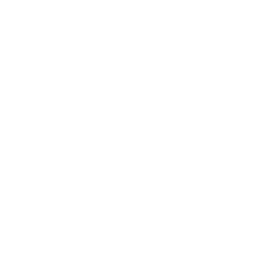
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analýza podobnosti kurikula</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Vysoké školství / Návrh akademických programů &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Manažerské shrnutí

Tento notebook měří překryv kurikula napříč univerzitním katalogem kurzů pomocí **PROC DISTANCE** s **METHOD=DJACCARD** — Jaccardovým koeficientem *nepodobnosti*, přirozenou vzdáleností pro binární data přítomnosti/nepřítomnosti. Každý kurz nese 40 binárních příznaků označujících, které akreditační výukové výstupy pokrývá, takže Jaccardova vzdálenost mezi dvěma kurzy je podíl pokrytých výstupů, které **nemají** společné (0 = shodné množiny výstupů, 1 = žádný sdílený výstup).

Analýza probíhá ve dvou částech. Nejprve napříč katalogem 100 kurzů profiluje šíři pokrytí výstupů podle katedry (PROC MEANS, PROC FREQ, krabicový graf pokrytí) a označuje výukové výstupy, které **žádný** kurz v katedře nepokrývá (mezery v pokrytí). Poté se zaměří na cílený panel 10 kurzů vybraných ze dvou kvantitativně nejvíce se překrývajících kateder — Statistics a Data Science — spočítá úplnou matici párových Jaccardových vzdáleností a seřadí nejbližší dvojice kurzů jako kandidáty k přezkoumání konsolidace. Cílem je poskytnout kurikulární komisi dva konkrétní artefakty: seřazený seznam nejpodobnějších kurzů a mapu mezer podle katedry a výstupu.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binární pokrytí výukových výstupů na kurz (40 příznaků výstupů) | 100 |
| WORK.PANEL10 | Konsolidační panel Statistika + Datová věda | 10 |

Katalog je syntetický. Příznaky výstupů jsou losovány s pravděpodobnostmi specifickými pro katedru, takže obory kladou důraz na různé shluky výstupů (informatika a matematika váží rané výstupy, laboratorní vědy váží střední pásmo), což dává analýze vzdáleností realistickou strukturu. Toto prostředí běží bez licence, takže pracovní katalog je omezen na 100 kurzů.

---

In [1]:
/* --------------------------------------------------------
   Generování syntetické matice výukových výstupů kurzů
   500 kurzů x 40 akreditačních výukových výstupů
   (nelicencovaný režim ponechá prvních 100)
   -------------------------------------------------------- */
data work.course_outcomes;
    CALL streaminit(42);
    DÉLKA department $15;
    POLE outcomes[40] lo_1 - lo_40;
    OPAKUJ course_id = 1 TO 500;
        course_label = cat('CRS', ZAPSAT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        KDYŽ dept_idx = 1 PAK department = 'Informatika';
        JINAK KDYŽ dept_idx = 2 PAK department = 'Matematika';
        JINAK KDYŽ dept_idx = 3 PAK department = 'Statistika';
        JINAK KDYŽ dept_idx = 4 PAK department = 'Inženýrství';
        JINAK KDYŽ dept_idx = 5 PAK department = 'Biologie';
        JINAK KDYŽ dept_idx = 6 PAK department = 'Chemie';
        JINAK KDYŽ dept_idx = 7 PAK department = 'Fyzika';
        JINAK department = 'Datová věda';
        /* Úroveň kurzu ovlivňuje šíři výstupů */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Shluky výstupů specifické pro katedru */
        OPAKUJ lo = 1 TO 40;
            base_prob = 0.15;
            /* Katedra 1-2 (informatika, matematika): důraz na výstupy 1-15 */
            KDYŽ dept_idx <= 2 AND lo <= 15 PAK
                base_prob = 0.4 + course_level * 0.05;
            /* Katedra 3-4 (statistika, inženýrství): důraz na výstupy 10-25 */
            JINAK KDYŽ dept_idx IN (3, 4) AND 10 <= lo <= 25 PAK
                base_prob = 0.35 + course_level * 0.05;
            /* Katedra 5-7 (biologie, chemie, fyzika): důraz na 20-35 */
            JINAK KDYŽ dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 PAK
                base_prob = 0.38 + course_level * 0.04;
            /* Katedra 8 (datová věda): široké pokrytí */
            JINAK KDYŽ dept_idx = 8 PAK
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        KONEC;
        VÝSTUP;
    KONEC;
    ODSTRANIT dept_idx course_level base_prob lo;
    ŠTÍTEK department='Katedra' course_label='Kurz' level_code='Úroveň';
SPUSTIT;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds


In [2]:
/* --------------------------------------------------------
   Generování metadat katalogu kurzů
   -------------------------------------------------------- */
data work.course_catalog;
    CALL streaminit(43);
    DÉLKA department $15;
    POLE format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    OPAKUJ course_id = 1 TO 500;
        course_label = cat('CRS-', ZAPSAT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        KDYŽ dept_idx = 1 PAK department = 'Informatika';
        JINAK KDYŽ dept_idx = 2 PAK department = 'Matematika';
        JINAK KDYŽ dept_idx = 3 PAK department = 'Statistika';
        JINAK KDYŽ dept_idx = 4 PAK department = 'Inženýrství';
        JINAK KDYŽ dept_idx = 5 PAK department = 'Biologie';
        JINAK KDYŽ dept_idx = 6 PAK department = 'Chemie';
        JINAK KDYŽ dept_idx = 7 PAK department = 'Fyzika';
        JINAK department = 'Datová věda';
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        VÝSTUP;
    KONEC;
    ODSTRANIT dept_idx format_idx;
    FORMÁT last_offered date9.;
    ŠTÍTEK department='Katedra' level_code='Úroveň';
SPUSTIT;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds


---

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                          Katedra           Obs           Mean
                                          ------------------------------------
                                          Biologie           10      0.2000000
                                          Chemie             19      0.2105263
                                          Datová věda        14      0.1428571
                                          Fyzika              7      0.2857143
                                          Informatika        13      0.3846154
                                          Inženýrství        17      0.0000000
                                          Matematika          9      0.6666667
                                          Statistika         11      0.0909091
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


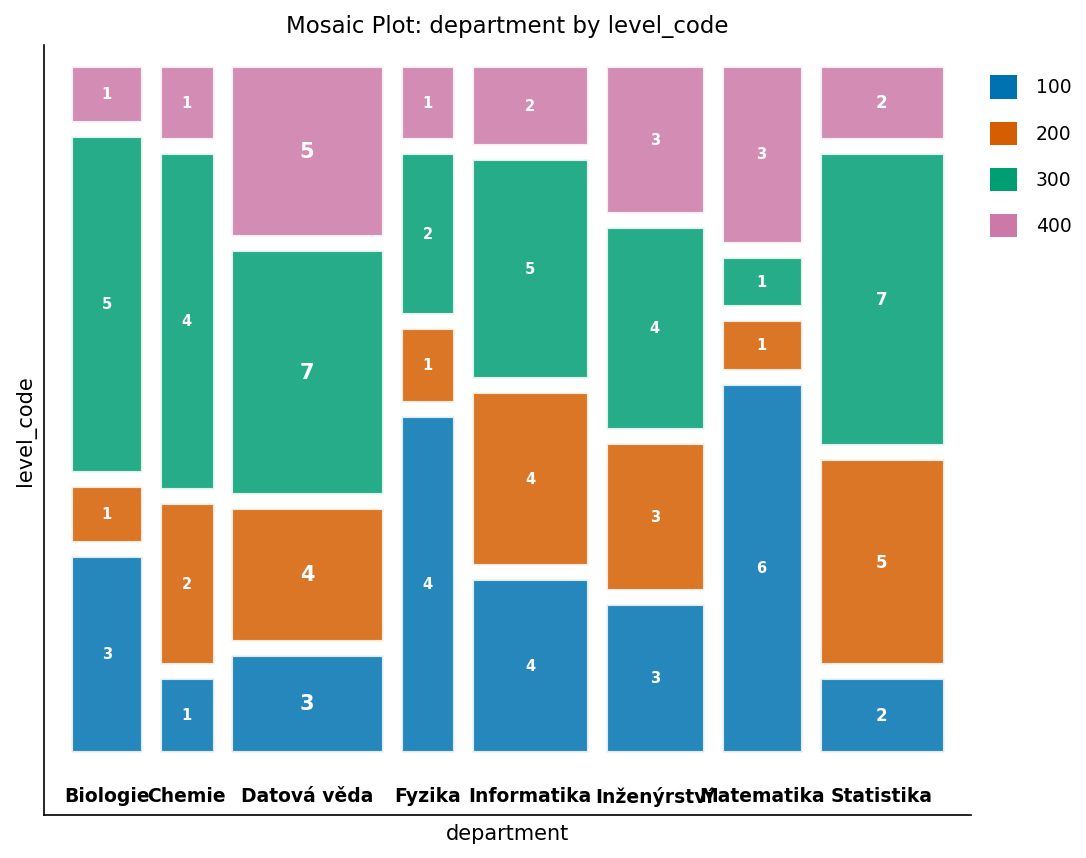

In [3]:
/* --------------------------------------------------------
   Základní pokrytí výukových výstupů podle katedry
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.course_outcomes mean;
    TŘÍDA department;
    PROMĚNNÁ lo_1 - lo_40;
SPUSTIT;

PROCEDURA ČETNOSTI data=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
SPUSTIT;

---


NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


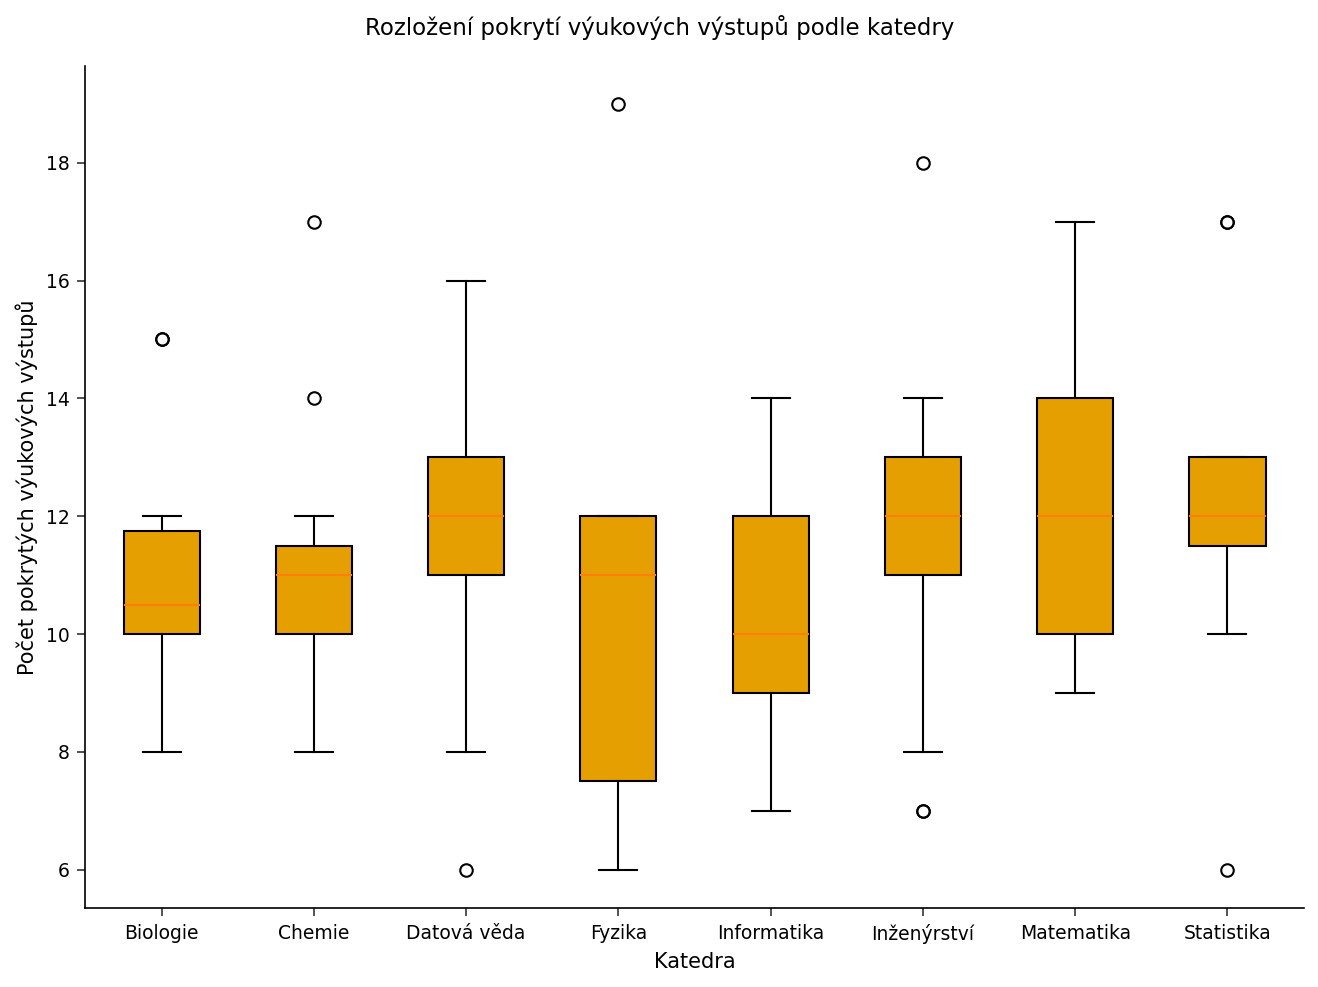

In [4]:
/* --------------------------------------------------------
   Hustota pokrytí výstupů podle katedry
   -------------------------------------------------------- */
data work.outcome_counts;
    NASTAVIT work.course_outcomes;
    POLE outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
    ŠTÍTEK total_outcomes='Počet pokrytých výukových výstupů';
SPUSTIT;

PROCEDURA SGPLOT data=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS ŠTÍTEK='Počet pokrytých výukových výstupů';
    XAXIS ŠTÍTEK='Katedra';
    NÁZEV 'Rozložení pokrytí výukových výstupů podle katedry';
SPUSTIT;

---

In [5]:
/* --------------------------------------------------------
   Konsolidační panel: prvních 10 kurzů statistiky / datové
   vědy (dvou kvantitativně nejvíce se překrývajících kateder).
   Přeznačíme je P01-P10 sekvenčním čítačem, aby čtvercová
   výstupní matice vzdáleností OUT= měla čisté, adresovatelné
   sloupce, poté spočítáme úplnou matici párových Jaccardových
   vzdáleností pomocí METHOD=DJACCARD
   (0 = shodné množiny výstupů, 1 = žádný sdílený výstup).
   -------------------------------------------------------- */
data work.panel10;
    NASTAVIT work.course_outcomes(KDE=(department IN ('Statistika' 'Datová věda')));
    UCHOVAT seq 0;
    seq + 1;
    KDYŽ seq > 10 PAK ZASTAVIT;
    panel_id = cat('P', ZAPSAT(seq, z2.));
    ODSTRANIT seq;
SPUSTIT;

PROCEDURA TISK data=work.panel10 noobs ŠTÍTEK;
    PROMĚNNÁ panel_id course_label department level_code;
    ŠTÍTEK panel_id = 'ID panelu' course_label = 'Kurz'
          department = 'Katedra' level_code = 'Úroveň';
    NÁZEV 'Konsolidační panel: kurzy statistiky a datové vědy';
SPUSTIT;

PROCEDURA distance data=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    PROMĚNNÁ nominal(lo_1 - lo_40);
    id panel_id;
SPUSTIT;

PROCEDURA TISK data=work.panel_dist noobs;
    NÁZEV 'Matice párových Jaccardových vzdáleností (10 kurzů)';
SPUSTIT;

                                   Konsolidační panel: kurzy statistiky a datové vědy                                   

ID panelu     Kurz        Katedra    Úroveň
P01        CRS0003  Datová věda         300
P02        CRS0006  Statistika          300
P03        CRS0014  Datová věda         300
P04        CRS0015  Statistika          300
P05        CRS0017  Statistika          200
P06        CRS0019  Datová věda         100
P07        CRS0022  Statistika          400
P08        CRS0033  Datová věda         200
P09        CRS0038  Statistika          100
P10        CRS0040  Statistika          100

                                   Konsolidační panel: kurzy statistiky a datové vědy                                   

                                  Matice párových Jaccardových vzdáleností (10 kurzů)                                   

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P0


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Přeskládání čtvercové matice vzdáleností na seřazený seznam
   dvojic kurzů. Sloupce vzdáleností OUT= jsou adresovány
   explicitním seznamem názvů (P01 P02 ... P10); ponechá se
   pouze striktní horní trojúhelník (col > row), takže každá
   neuspořádaná dvojice se objeví jednou a nulová diagonála se
   přeskočí. Pět nejbližších dvojic jsou kandidáti k přezkoumání
   konsolidace.
   -------------------------------------------------------- */
data work.similar_courses;
    NASTAVIT work.panel_dist;
    POLE d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    DÉLKA course_a course_b $8;
    course_a = _name_;
    row + 1;
    OPAKUJ col = 1 TO 10;
        KDYŽ col > row PAK OPAKUJ;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            VÝSTUP;
        KONEC;
    KONEC;
    PONECHAT course_a course_b jaccard_dist;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    PROMĚNNÁ jaccard_dist;
    ŠTÍTEK jaccard_dist='Jaccardova vzdálenost';
    NÁZEV 'Rozdělení párových Jaccardových vzdáleností (45 dvojic kurzů)';
SPUSTIT;

PROCEDURA ŘADIT data=work.similar_courses; PODLE jaccard_dist; SPUSTIT;

data work.top_pairs;
    NASTAVIT work.similar_courses;
    pair_rank = _n_;
    KDYŽ pair_rank <= 5;
SPUSTIT;

PROCEDURA TISK data=work.top_pairs noobs ŠTÍTEK;
    PROMĚNNÁ pair_rank course_a course_b jaccard_dist;
    ŠTÍTEK pair_rank = 'Pořadí' course_a = 'Kurz A'
          course_b = 'Kurz B' jaccard_dist = 'Jaccardova vzdálenost';
    NÁZEV 'Pět nejbližších dvojic kurzů (kandidáti na konsolidaci)';
SPUSTIT;

                             Rozdělení párových Jaccardových vzdáleností (45 dvojic kurzů)                              

                                                  The MEANS Procedure

 Variable      Label                         N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccardova vzdálenost        45       0.588            0.762       0.826       0.818       0.962
 --------------------------------------------------------------------------------------------------------------

                                Pět nejbližších dvojic kurzů (kandidáti na konsolidaci)                                 

  Pořadí  Kurz A  Kurz B   Jaccardova vzdálenost
       1  P02     P10                      0.588
       2  P03     P04                        0.6
       3  P03     P05                      0.667
       4  P02     P04                   


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                        Nepokryté výukové výstupy podle katedry                                         

                                                   The FREQ Procedure

Katedra           Frequency    Percent
---------------------------------------
Biologie                  8     26.67
Chemie                    2      6.67
Fyzika                    8     26.67
Informatika               3     10.00
Inženýrství               2      6.67
Matematika                4     13.33
Statistika                3     10.00
                                      Ukázka mezer ve výstupech (prvních 12 z 30)                                       

 Katedra    Nepokrytý výstup
Biologie  LO02
Biologie  LO10
Biologie  LO15
Biologie  LO16
Biologie  LO17
Biologie  LO18
Biologie  LO36
Biologie  LO37
Chemie    LO02
Chemie    LO12
Fyzika    LO02
Fyzika    LO03

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


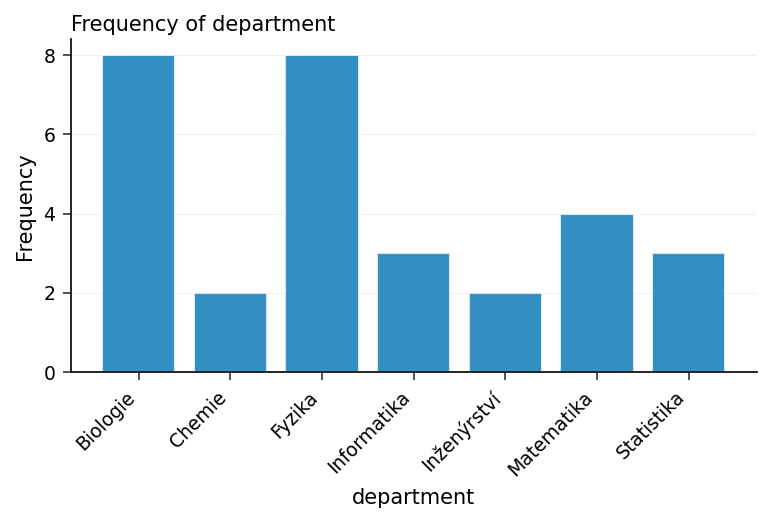

In [7]:
/* --------------------------------------------------------
   Mezery ve výstupech: výukové výstupy, které NEPOKRÝVÁ žádný
   kurz v katedře. PROC MEANS sečte každý binární příznak výstupu
   v rámci katedry; součet nula znamená, že výstup v katalogu
   dané katedry chybí.
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.course_outcomes sum NOPRINT;
    TŘÍDA department;
    PROMĚNNÁ lo_1 - lo_40;
    VÝSTUP out=work.dept_coverage(KDE=(_type_=1))
        sum=lo_1 - lo_40;
SPUSTIT;

data work.outcome_gaps;
    NASTAVIT work.dept_coverage;
    POLE outcomes[40] lo_1 - lo_40;
    OPAKUJ lo = 1 TO 40;
        outcome_id = cat('LO', ZAPSAT(lo, z2.));
        courses_covering = outcomes[lo];
        KDYŽ courses_covering = 0 PAK OPAKUJ;
            gap_flag = 1;
            VÝSTUP;
        KONEC;
    KONEC;
    PONECHAT department outcome_id courses_covering gap_flag;
SPUSTIT;

PROCEDURA ČETNOSTI data=work.outcome_gaps;
    TABLES department / nocum;
    ŠTÍTEK department='Katedra';
    NÁZEV 'Nepokryté výukové výstupy podle katedry';
SPUSTIT;

PROCEDURA TISK data=work.outcome_gaps(obs=12) noobs ŠTÍTEK;
    PROMĚNNÁ department outcome_id;
    ŠTÍTEK department = 'Katedra' outcome_id = 'Nepokrytý výstup';
    NÁZEV 'Ukázka mezer ve výstupech (prvních 12 z 30)';
SPUSTIT;

---

### Interpretace

**Konsolidační panel.** Napříč 45 neuspořádanými dvojicemi v 10kurzovém panelu Statistika / Datová věda se Jaccardova vzdálenost pohybuje od 0.588 do 0.962 s mediánem 0.826 (průměr 0.818). Nejbližší dvojicí je P02 a P10 na vzdálenosti 0.588, následovaná P03–P04 na 0.600 a P03–P05 na 0.667. I nejpodobnější kurzy se stále liší přibližně v 59 % svých pokrytých výstupů, takže tento katalog neobsahuje **žádné téměř duplicitní kurzy** — neexistuje dvojice, kterou by komise mohla přímo sloučit. Seřazený seznam místo toho ukazuje na hrstku dvojic, které stojí za ruční srovnání sylabů před dalším cyklem katalogu; dvojice s nejvyšší vzdáleností (kolem 0.962) potvrzují, že kurzy Statistika a Datová věda, přestože sdílejí sousedství v rámci katedry, pokrývají skutečně odlišné množiny výstupů.

**Mezery ve výstupech.** V katalogu se objeví třicet mezer podle katedry a výstupu. Nejvíce jich nesou laboratorně náročné obory: **Biologie** a **Fyzika** ponechávají každý 8 ze 40 akreditačních výstupů nepokrytých, následuje **Matematika** (4). Kvantitativní katedry jsou pokryty nejlépe — **Chemie** a **Inženýrství** míjejí pouze 2 výstupy každá. Tyto mezery jsou přirozeným cílem pro vývoj nových kurzů nebo pro cross-listing: výstup chybějící v celé katedře je rizikem pokrytí při obnově akreditace, zatímco konsolidační seznam řeší opačný problém redundantní práce. Dohromady oba artefakty umožňují komisi utáhnout katalog z obou konců — ořezat překryv a zaplnit prázdná místa — pomocí jediné množinově založené míry vzdálenosti.

---

In [8]:
/* --------------------------------------------------------
   Export seřazených kandidátů na konsolidaci a mapy mezer
   ve výstupech podle katedry pro kurikulární komisi.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>